# Baseline Model 

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import missingno as msno
import seaborn as sns
import matplotlib as plt

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
df = pd.read_csv('data/Train.csv')
#df_Test = pd.read_csv('data/Test.csv')

### Correlation of Features

In [3]:
# Function to get number density columns 
# the tropospheric_X_column_number_density measures density closer to Earth’s surface
def get_number_density_columns(df):
    return [
        col for col in df.columns 
        if "column_number_density" in col and "tropospheric" in col
    ]

In [4]:
cols = get_number_density_columns(df)
print(cols)


['L3_NO2_tropospheric_NO2_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density_amf']


In [5]:
selected_cols = ["Place_ID", "target", "temperature_2m_above_ground", "u_component_of_wind_10m_above_ground",'L3_NO2_tropospheric_NO2_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density', 'L3_HCHO_tropospheric_HCHO_column_number_density_amf']
df_selected = df[selected_cols]  

In [6]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID                                             30557 non-null  object 
 1   target                                               30557 non-null  float64
 2   temperature_2m_above_ground                          30557 non-null  float64
 3   u_component_of_wind_10m_above_ground                 30557 non-null  float64
 4   L3_NO2_tropospheric_NO2_column_number_density        21888 non-null  float64
 5   L3_HCHO_tropospheric_HCHO_column_number_density      23132 non-null  float64
 6   L3_HCHO_tropospheric_HCHO_column_number_density_amf  23132 non-null  float64
dtypes: float64(6), object(1)
memory usage: 1.6+ MB


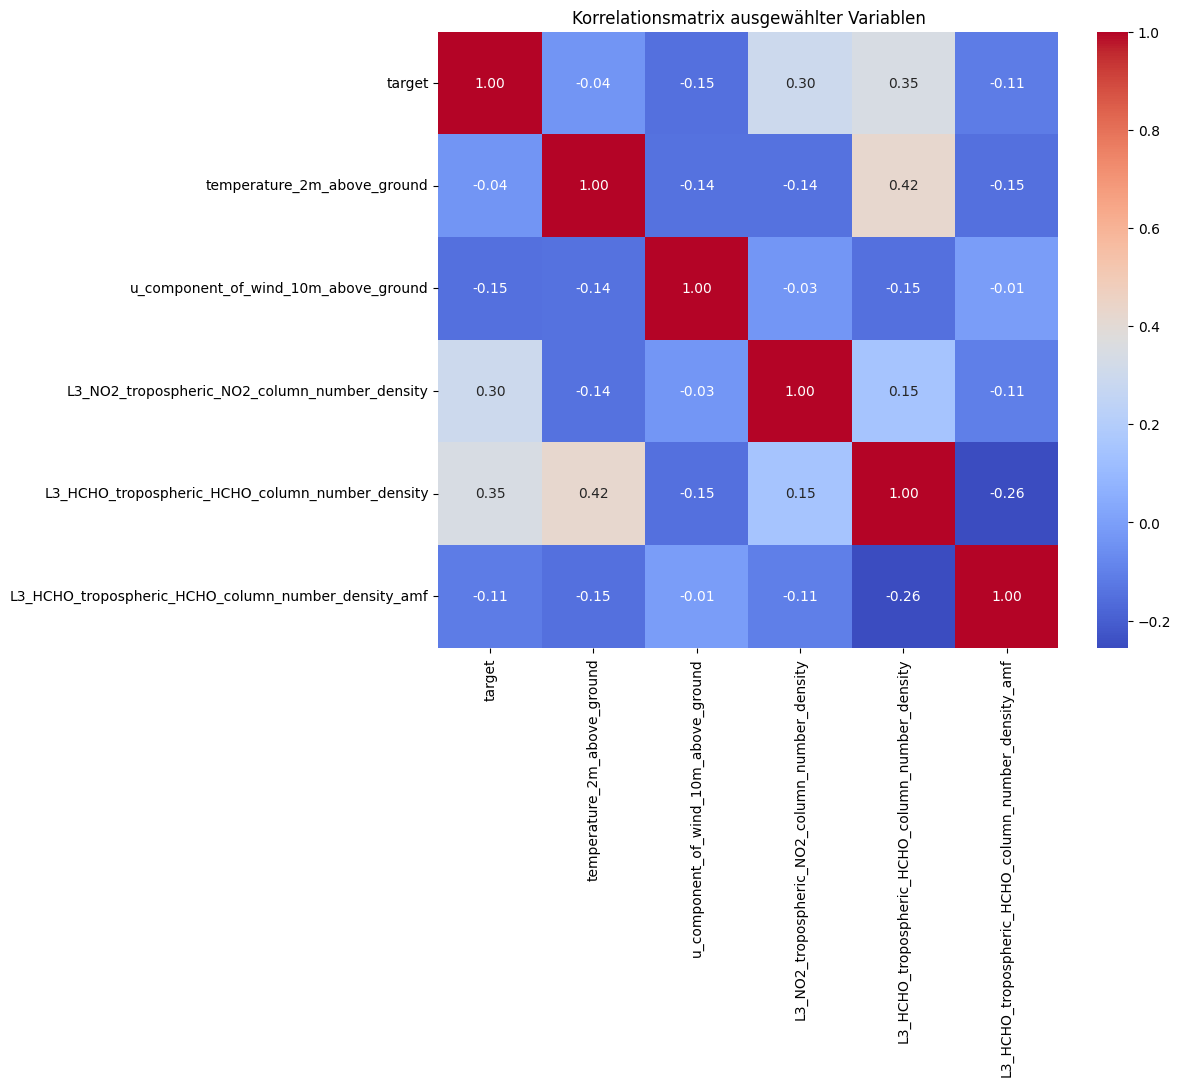

In [7]:
# Plot correlation matrix   
corr = df_selected.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korrelationsmatrix ausgewählter Variablen")
plt.show()

### Features and Train/ Test-Split

In [8]:
features = [
    #'temperature_2m_above_ground',
    #'u_component_of_wind_10m_above_ground',
    'L3_NO2_tropospheric_NO2_column_number_density',
    'L3_HCHO_tropospheric_HCHO_column_number_density'
]
X = df[features]
y = df['target']

In [9]:
X.isnull().sum() * 100 / len(X)

L3_NO2_tropospheric_NO2_column_number_density      28.369932
L3_HCHO_tropospheric_HCHO_column_number_density    24.298851
dtype: float64

In [10]:
# fill missing values with mean
X = X.fillna(X.mean())

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42
)

In [12]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (24445, 2)
Test set size: (6112, 2)


### Modeling

In [14]:
def print_pretty_summary(name, y_actual, y_pred):
    print(name)
    print('=======================')
    
    r2 = r2_score(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    print(f"R²:   {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print()

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

print_pretty_summary('baseline model on TEST', y_test, y_pred)
#print("Mean squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
#print("R^2 Score:", r2_score(y_test, y_pred))
print_pretty_summary('baseline model on TRAIN', y_train, y_pred_train)


baseline model on TEST
R²:   0.138
RMSE: 43.538

baseline model on TRAIN
R²:   0.142
RMSE: 43.401



In [15]:
# The baseline linear regression model explains around 13% of the variance in the target variable.

# Plotting 

In [20]:
df_y_pred_test = pd.DataFrame(y_pred)

y_pred_series = df_y_pred_test.iloc[:, 0].reset_index(drop=True)
y_pred_series.name = 'y_pred'
df_pred_concat = pd.concat(
    [
        df_test.Date.reset_index(drop=True),
        df_test.Place_ID.reset_index(drop=True),
        y_pred_series
    ],
    axis=1
)

df_pred_concat.columns = ['Date', 'Place_ID', 'y_pred']

df_pred_concat.groupby(by='Place_ID').value_counts()

Place_ID  Date        y_pred   
010Q650   2020-01-08  31.780483    1
          2020-01-09  54.851361    1
          2020-04-03  38.316065    1
          2020-04-02  52.443889    1
          2020-03-25  63.454546    1
                                  ..
YWSFY6Q   2020-01-24  61.623065    1
          2020-01-23  54.092168    1
          2020-01-09  44.610481    1
          2020-01-06  60.911549    1
          2020-03-11  45.787665    1
Name: count, Length: 6112, dtype: int64

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_actual_vs_pred_over_time(
    model, X, y, meta_df,
    date_col="Date", place_col="Place_ID",
    place_id=None, rolling=None, title_prefix="PM2.5"
):
    """
    Plot Actual vs. Predicted PM2.5 über die Zeit.
    
model: trainiertes Modell oder Pipeline mit .predict()
X, y: Trainings-Features/-Ziel (y als Series, index wie X)
meta_df: DataFrame mit Date & Place_ID für dieselben Zeilen (Index == X.index)
place_id: optional, nur diesen Ort plotten (z.B. '010G650')
rolling: optionales Fenster (z.B. 3) für gleitenden Mittelwert
"""

    # Vorhersagen
    y_pred = model.predict(X)

    # Zusammenführen und sortieren
    dfp = pd.DataFrame({
        "Date": meta_df.Date,
        "Place_ID": meta_df[place_col],
        "Actual": y.values if isinstance(y, pd.Series) else y,
        "Pred": y_pred
    }, index=meta_df.index)

    if place_id is not None:
        dfp = dfp[dfp["Place_ID"] == place_id]

    dfp = dfp.sort_values("Date")

    # optional glätten
    if rolling is not None and rolling > 1:
        dfp["Actual_plot"] = dfp["Actual"].rolling(rolling, min_periods=1).mean()
        dfp["Pred_plot"]   = dfp["Pred"].rolling(rolling, min_periods=1).mean()
    else:
        dfp["Actual_plot"], dfp["Pred_plot"] = dfp["Actual"], dfp["Pred"]

    # Plot
    plt.figure(figsize=(12,4))
    plt.plot(dfp["Date"], dfp["Actual_plot"], label="Actual PM2.5")
    plt.plot(dfp["Date"], dfp["Pred_plot"],   label="Predicted PM2.5")
    ttl = f"{title_prefix} Trend"
    if place_id is not None:
        ttl += f" — {place_id}"
    plt.title(ttl)
    plt.xlabel("Date")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

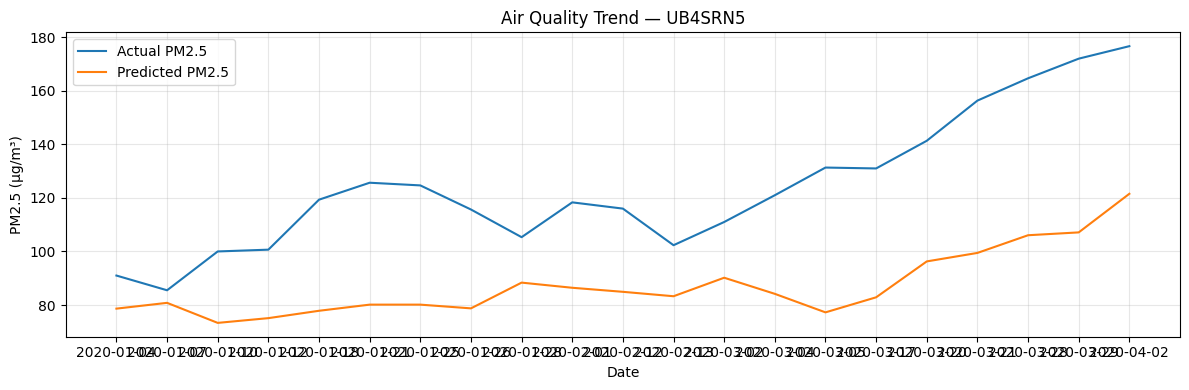

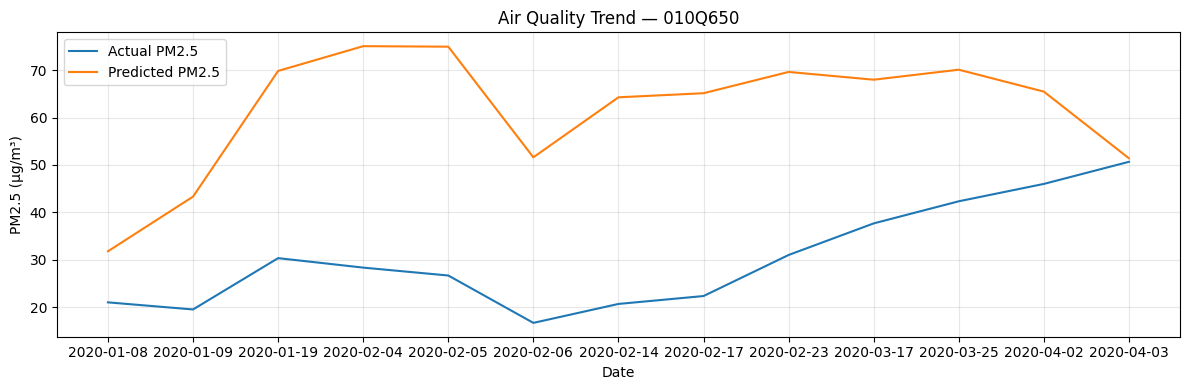

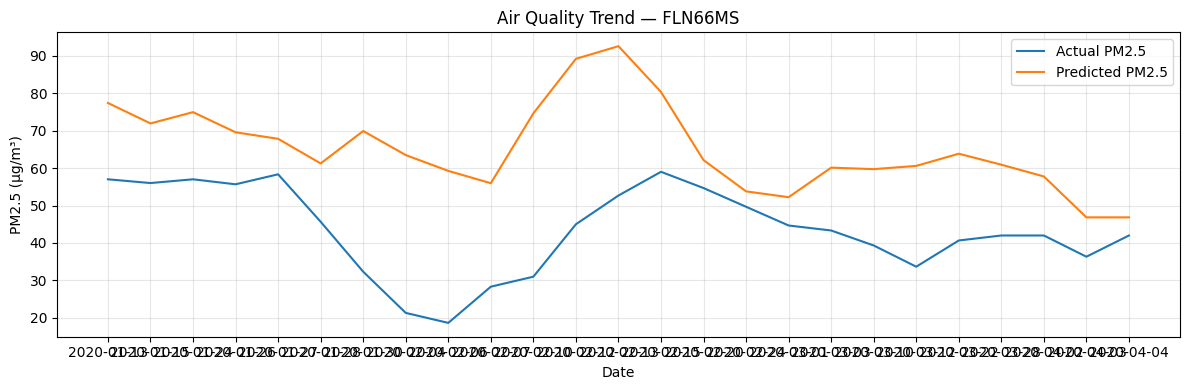

In [23]:
# 1) Plot für einen Ort (wie im Beispielbild)
plot_actual_vs_pred_over_time(model1, X_test, y_test, df_pred_concat,
                              place_id="UB4SRN5", rolling=3, title_prefix="Air Quality")

# 2) Plot für einen Ort (wie im Beispielbild)
plot_actual_vs_pred_over_time(model1, X_test, y_test, df_pred_concat,
                              place_id="010Q650", rolling=3, title_prefix="Air Quality")

# 3) Plot für einen Ort (wie im Beispielbild)
plot_actual_vs_pred_over_time(model1, X_test, y_test, df_pred_concat,
                              place_id="FLN66MS", rolling=3, title_prefix="Air Quality")